# Driver Drowsiness & Yawn Detection System

### Developed by: Minahil Amir

## Project Description

This project is an AI-based Driver Drowsiness and Yawn Detection System developed by **Minahil Amir**. The system monitors a driver's facial behavior through a webcam and identifies two key signs of fatigue: **prolonged eye closure** and **yawning**.

A custom Convolutional Neural Network (CNN) was trained from scratch on a labeled dataset of eye and mouth states, then deployed through a live, interactive web interface where predictions and confidence scores are shown in real time.

## Main Objectives

- Detect eye closure and yawning from the driver's facial features.
- Monitor the driver continuously through a live webcam feed.
- Flag possible drowsiness with a clear, real-time alert and confidence score.
- Provide an accessible, browser-based interface — no local setup required to try it.
- Demonstrate a complete applied deep learning + computer vision pipeline, from raw data to a working demo.

## Technologies Used

- Python
- TensorFlow / Keras (CNN with Batch Normalization for stable training)
- OpenCV (face, eye, and mouth region detection via Haar Cascades)
- Gradio (real-time web interface)
- Google Colab (training and deployment environment)
- Webcam for live real-time detection

## How the System Works

1. The webcam captures a live video frame of the driver's face.
2. A face detector locates the face, then separately isolates the eye region and the mouth region.
3. Each region is passed through the trained CNN, which classifies eye state (Open/Closed) and mouth state (Yawn/No Yawn) independently.
4. If the eyes are detected closed, or a yawn is detected, the system raises a **DROWSY** alert along with the model's confidence percentage.
5. Otherwise, the system reports the driver as **ALERT**.

## Model Performance

The CNN was trained with data augmentation and early stopping to reduce overfitting, achieving an overall validation accuracy of **~73–80%** across four classes (Open, Closed, Yawn, No Yawn). Eye-state detection is highly reliable; yawn detection is functional but less consistent, which is a known limitation and an area for future improvement (e.g. more training data, a dedicated mouth-detection model).

## Expected Outcome

The final system provides a real-time, browser-accessible demonstration of driver fatigue monitoring, combining two independent detection signals into a single alert system. This project demonstrates the practical application of deep learning, computer vision, and interactive deployment in the context of road-safety technology.

**Developed by: Minahil Amir**
**Project Type: AI / Computer Vision / Deep Learning**

In [ ]:
!pip install opencv-python==4.10.0.84 -q

In [ ]:
!pip install gradio -q

In [112]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os, cv2, time
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from IPython.display import display, Javascript, Audio
from google.colab.output import eval_js
from base64 import b64decode
from google.colab import files
import warnings
warnings.filterwarnings('ignore')
import gradio as gr
import numpy as np
import cv2

In [113]:
import zipfile

with zipfile.ZipFile('/content/archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('data')

print(os.listdir('data'))

['train']


In [114]:
print(os.listdir('data/train'))

['yawn', 'no_yawn', 'Open', 'Closed']


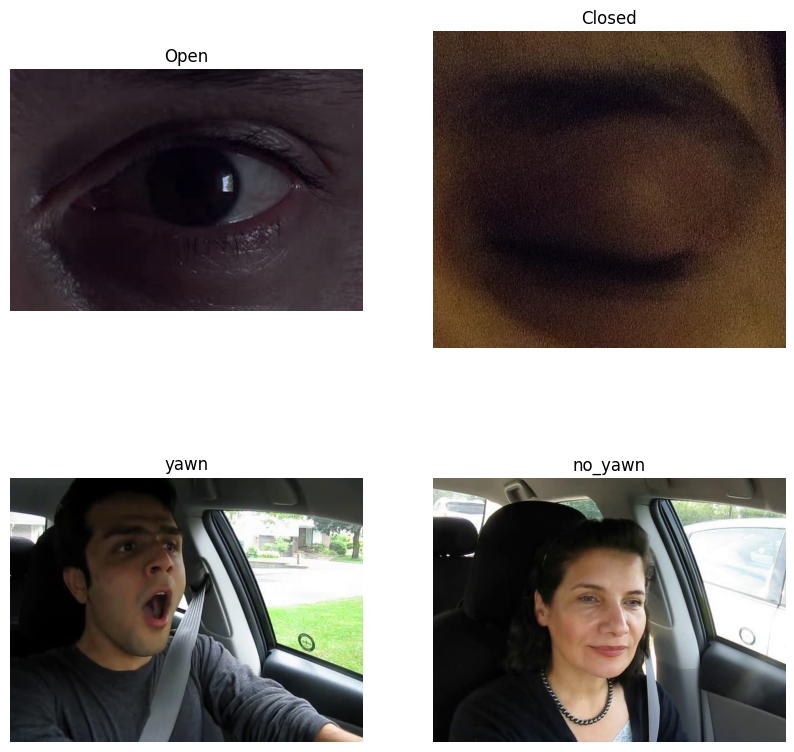

In [115]:
data_dir = 'data/train'
classes = ['Open', 'Closed', 'yawn', 'no_yawn']

plt.figure(figsize=(10, 10))
for i, cls in enumerate(classes):
    folder = os.path.join(data_dir, cls)
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

In [116]:
for cls in classes:
    folder = os.path.join(data_dir, cls)
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)
    img = cv2.imread(img_path)
    print(cls, '→', img.shape)

print('Total images per class:')
for cls in classes:
    folder = os.path.join(data_dir, cls)
    print(cls, '→', len(os.listdir(folder)))

Open → (238, 347, 3)
Closed → (639, 710, 3)
yawn → (480, 640, 3)
no_yawn → (480, 640, 3)
Total images per class:
Open → 726
Closed → 726
yawn → 723
no_yawn → 725


In [117]:
img_size = 145

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 2321 images belonging to 4 classes.
Found 579 images belonging to 4 classes.


In [118]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [119]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [122]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 26s 353ms/step - accuracy: 0.6622 - loss: 0.7689 - val_accuracy: 0.2504 - val_loss: 22.9365
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 334ms/step - accuracy: 0.6691 - loss: 0.6511 - val_accuracy: 0.2591 - val_loss: 11.5523
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 25s 337ms/step - accuracy: 0.6467 - loss: 0.7443 - val_accuracy: 0.4335 - val_loss: 2.5232
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 25s 337ms/step - accuracy: 0.6566 - loss: 0.7232 - val_accuracy: 0.6166 - val_loss: 2.5512
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 24s 332ms/step - accuracy: 0.7066 - loss: 0.5648 - val_accuracy: 0.6200 - val_loss: 0.8091
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 334ms/step - accuracy: 0.7014 - loss: 0.5498 - val_accuracy: 0.7841 - val_loss: 0.4332
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 25s 339ms/step - accuracy: 0.7070 - loss: 0.5367 - val_accuracy: 0.6788 - val_loss: 0.4860
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 24s 334ms/step - accuracy: 0.7290 - loss: 0.4850 - val_ac

In [123]:
print(train_generator.class_indices)

{'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step
              precision    recall  f1-score   support

      Closed       0.91      0.97      0.94       145
        Open       0.96      0.90      0.93       145
     no_yawn       0.53      0.54      0.54       145
        yawn       0.53      0.51      0.52       144

    accuracy                           0.73       579
   macro avg       0.73      0.73      0.73       579
weighted avg       0.73      0.73      0.73       579



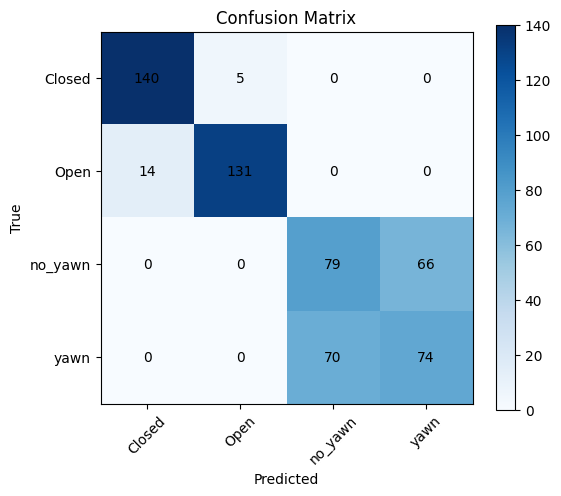

In [124]:
import numpy as np

val_generator.reset()
predictions = model.predict(val_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

print(classification_report(true_classes, predicted_classes, target_names=class_labels))

cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(len(class_labels)), class_labels, rotation=45)
plt.yticks(range(len(class_labels)), class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        plt.text(j, i, cm[i][j], ha='center', va='center')
plt.show()

In [125]:
model.save('drowsiness_model.h5')

In [127]:
from IPython.display import display, Javascript

display(Javascript("""
(async () => {
    const video = document.createElement('video');

    video.id = 'driverCamera';
    video.width = 640;
    video.height = 480;
    video.autoplay = true;
    video.playsInline = true;
    video.style.display = 'block';

    document.body.appendChild(video);

    const stream = await navigator.mediaDevices.getUserMedia({
        video: true,
        audio: false
    });

    video.srcObject = stream;

    await video.play();

    console.log("Camera started!");
})();
"""))

<IPython.core.display.Javascript object>

In [128]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2

def take_photo():
    js = Javascript('''
        async function takePhoto() {
            const video = document.createElement('video');
            video.style.display = 'none';
            document.body.appendChild(video);

            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            video.srcObject = stream;
            await video.play();

            // wait a moment for the camera to adjust
            await new Promise(resolve => setTimeout(resolve, 500));

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            video.remove();

            return canvas.toDataURL('image/jpeg', 0.9);
        }
    ''')
    display(js)
    data = eval_js('takePhoto()')
    header, encoded = data.split(',', 1)
    binary = b64decode(encoded)
    img_array = np.frombuffer(binary, dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    return img

<IPython.core.display.Javascript object>

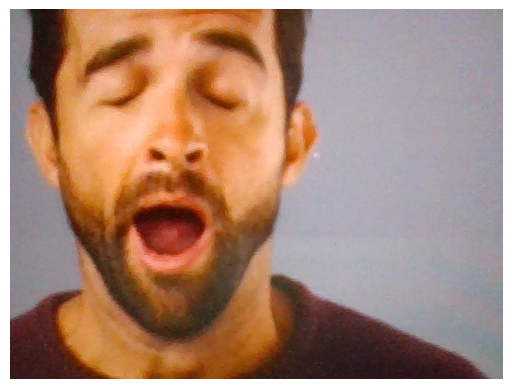

In [134]:
frame = take_photo()
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [135]:
class_labels = list(val_generator.class_indices.keys())

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_eye.xml'
)

def get_eye_crop(frame):

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=5
    )

    if len(faces) == 0:
        return None

    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])

    face_gray = gray[y:y+h, x:x+w]
    face_color = frame[y:y+h, x:x+w]

    eyes = eye_cascade.detectMultiScale(
        face_gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    if len(eyes) == 0:
        return None

    ex, ey, ew, eh = max(eyes, key=lambda e: e[2] * e[3])

    eye_crop = face_color[ey:ey+eh, ex:ex+ew]

    return eye_crop

In [136]:
def predict_eye_state(frame):

    eye_crop = get_eye_crop(frame)

    if eye_crop is None:
        return "No face/eyes detected", 0

    img = cv2.resize(eye_crop, (img_size, img_size))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)

    class_idx = np.argmax(pred[0])
    confidence = float(pred[0][class_idx])

    label = class_labels[class_idx]

    return label, confidence

<IPython.core.display.Javascript object>

Prediction: Open (61.1%)


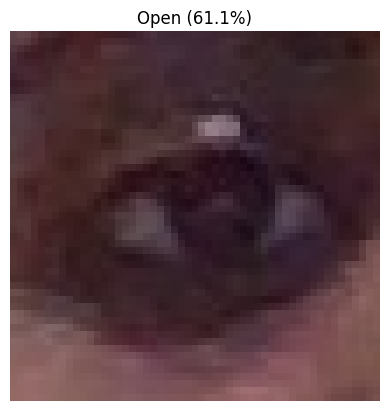

In [144]:
frame = take_photo()

label, confidence = predict_eye_state(frame)

print(f"Prediction: {label} ({confidence*100:.1f}%)")

eye_crop = get_eye_crop(frame)

if eye_crop is not None:

    plt.imshow(cv2.cvtColor(eye_crop, cv2.COLOR_BGR2RGB))

    plt.title(f"{label} ({confidence*100:.1f}%)")

    plt.axis("off")

    plt.show()

else:
    print("No face/eyes detected.")

In [147]:
import time
from IPython.display import Audio, display

closed_counter = 0

CLOSED_THRESHOLD = 3
MAX_CHECKS = 10
CAPTURE_INTERVAL = 1

alert_sound_url = "https://actions.google.com/sounds/v1/alarms/beep_short.ogg"

print("🚗 Starting Driver Drowsiness Monitoring...")
print("The system will check your eyes repeatedly.")

for i in range(MAX_CHECKS):

    frame = take_photo()

    label, confidence = predict_eye_state(frame)

    if label == "Closed":
        closed_counter += 1
    else:
        closed_counter = 0

    if closed_counter >= CLOSED_THRESHOLD:

        status = "⚠️ DROWSY - ALERT!"

        print(
            f"Check {i+1}: {label} "
            f"({confidence*100:.1f}%) → {status}"
        )

        display(Audio(url=alert_sound_url, autoplay=True))

    else:

        status = "Normal"

        print(
            f"Check {i+1}: {label} "
            f"({confidence*100:.1f}%) → {status}"
        )

    time.sleep(CAPTURE_INTERVAL)

🚗 Starting Driver Drowsiness Monitoring...
The system will check your eyes repeatedly.


<IPython.core.display.Javascript object>

Check 1: Open (60.3%) → Normal


<IPython.core.display.Javascript object>

Check 2: Open (72.9%) → Normal


...

Check 8: No face/eyes detected (0.0%) → Normal


<IPython.core.display.Javascript object>

Check 9: No face/eyes detected (0.0%) → Normal


<IPython.core.display.Javascript object>

Check 10: Open (88.7%) → Normal


In [148]:
if label == "Closed":
    print("⚠️ Possible Drowsiness Detected")
else:
    print("✅ Driver appears alert")

✅ Driver appears alert


In [149]:
import time

closed_counter = 0
CLOSED_THRESHOLD = 3
CAPTURE_INTERVAL = 1

print("Starting drowsiness monitor... Run this cell, then check each snapshot below.")

for i in range(10):
    frame = take_photo()
    label, confidence = predict_frame(frame)

    print(f"Check {i+1}: {label} ({confidence*100:.1f}%)")

    if label == 'Closed':
        closed_counter += 1
    else:
        closed_counter = 0

    if closed_counter >= CLOSED_THRESHOLD:
        print("⚠️ DROWSINESS ALERT — eyes closed too long!")

    time.sleep(CAPTURE_INTERVAL)

Starting drowsiness monitor... Run this cell, then check each snapshot below.


<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Check 1: Open (99.6%)


<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Check 2: Open (99.8%)


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Check 8: Open (99.8%)


<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Check 9: Open (93.0%)


<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Check 10: Open (97.4%)


In [150]:
import time
from IPython.display import Audio, display

closed_counter = 0
CLOSED_THRESHOLD = 3
CAPTURE_INTERVAL = 1
MAX_CHECKS = 20

alert_sound_url = "https://actions.google.com/sounds/v1/alarms/beep_short.ogg"

for i in range(MAX_CHECKS):
    frame = take_photo()
    label, confidence = predict_frame(frame)

    status = "Normal"
    if label == 'Closed':
        closed_counter += 1
    else:
        closed_counter = 0

    if closed_counter >= CLOSED_THRESHOLD:
        status = "⚠️ DROWSY - ALERT!"
        display(Audio(url=alert_sound_url, autoplay=True))

    print(f"Check {i+1}: {label} ({confidence*100:.1f}%) → {status}")
    time.sleep(CAPTURE_INTERVAL)

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Check 1: Open (99.7%) → Normal


<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Check 2: Open (98.7%) → Normal


<IPython.core.display.Javascript object>

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Check 18: Closed (85.2%) → Normal


<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Check 19: Open (95.0%) → Normal


<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Check 20: Open (50.9%) → Normal


In [151]:
import cv2
print(cv2.__version__)
print(cv2.__file__)
print([x for x in dir(cv2) if 'Cascade' in x])

4.10.0
/usr/local/lib/python3.13/dist-packages/cv2/__init__.py
['BaseCascadeClassifier', 'CascadeClassifier', 'CascadeClassifier_convert']


In [152]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

def get_eye_crop(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    if len(faces) == 0:
        return None

    (x, y, w, h) = faces[0]
    face_gray = gray[y:y+h, x:x+w]
    face_color = frame[y:y+h, x:x+w]

    eyes = eye_cascade.detectMultiScale(face_gray)

    if len(eyes) == 0:
        return None

    (ex, ey, ew, eh) = eyes[0]
    eye_crop = face_color[ey:ey+eh, ex:ex+ew]

    return eye_crop

<IPython.core.display.Javascript object>

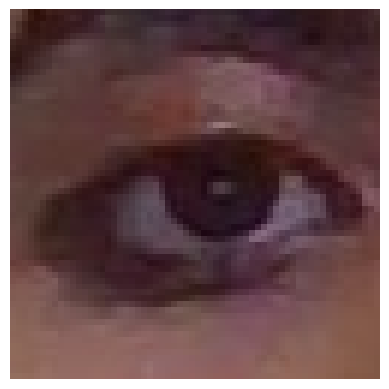

In [158]:
frame = take_photo()
eye_crop = get_eye_crop(frame)

if eye_crop is not None:
    plt.imshow(cv2.cvtColor(eye_crop, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
else:
    print("No face/eyes detected — try adjusting lighting or distance from camera")

In [159]:
def predict_eye_state(frame):
    eye_crop = get_eye_crop(frame)

    if eye_crop is None:
        return "No face/eyes detected", 0

    img = cv2.resize(eye_crop, (img_size, img_size))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    class_idx = np.argmax(pred)
    confidence = np.max(pred)

    return class_labels[class_idx], confidence

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediction: Open (63.5%)


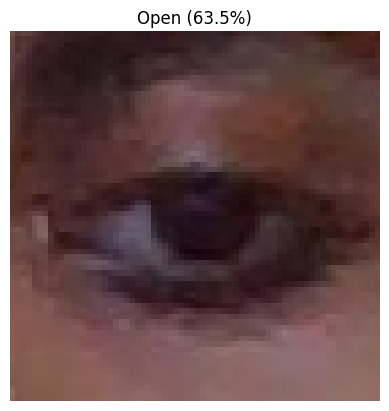

In [160]:
frame = take_photo()
label, confidence = predict_eye_state(frame)
print(f"Prediction: {label} ({confidence*100:.1f}%)")

eye_crop = get_eye_crop(frame)
if eye_crop is not None:
    plt.imshow(cv2.cvtColor(eye_crop, cv2.COLOR_BGR2RGB))
    plt.title(f'{label} ({confidence*100:.1f}%)')
    plt.axis('off')
    plt.show()

In [163]:
import time
from IPython.display import Audio, display

closed_counter = 0
CLOSED_THRESHOLD = 3
CAPTURE_INTERVAL = 1
MAX_CHECKS = 20
alert_sound_url = "https://actions.google.com/sounds/v1/alarms/beep_short.ogg"

for i in range(MAX_CHECKS):
    frame = take_photo()
    label, confidence = predict_eye_state(frame)

    status = "Normal"
    if label == 'Closed':
        closed_counter += 1
    else:
        closed_counter = 0

    if closed_counter >= CLOSED_THRESHOLD:
        status = "DROWSY - ALERT!"
        display(Audio(url=alert_sound_url, autoplay=True))

    print(f"Check {i+1}: {label} ({confidence*100:.1f}%) -> {status}")
    time.sleep(CAPTURE_INTERVAL)

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Check 1: Closed (61.4%) -> Normal


<IPython.core.display.Javascript object>

Check 2: No face/eyes detected (0.0%) -> Normal


<IPython.core.display.Javascript object>

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Check 18: Open (69.6%) -> Normal


<IPython.core.display.Javascript object>

Check 19: No face/eyes detected (0.0%) -> Normal


<IPython.core.display.Javascript object>

Check 20: No face/eyes detected (0.0%) -> Normal


In [164]:
def get_mouth_crop(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    if len(faces) == 0:
        return None
    (x, y, w, h) = max(faces, key=lambda f: f[2]*f[3])
    face_color = frame[y:y+h, x:x+w]
    return face_color[int(h*0.65):h, 0:w]

def predict_region(crop):
    if crop is None or crop.size == 0:
        return None, 0
    img = cv2.resize(crop, (img_size, img_size)).astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)
    pred = model.predict(img, verbose=0)
    idx = np.argmax(pred[0])
    return class_labels[idx], float(pred[0][idx])

def web_predict(frame):
    if frame is None:
        return "No camera image", "No camera image", "Waiting..."
    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

    eye_crop = get_eye_crop(frame)
    mouth_crop = get_mouth_crop(frame)

    eye_label, eye_conf = predict_region(eye_crop)
    mouth_label, mouth_conf = predict_region(mouth_crop)

    if eye_label == "Closed":
        status = "⚠️ DROWSINESS DETECTED (eyes closed)"
    elif mouth_label == "yawn":
        status = "⚠️ DROWSINESS DETECTED (yawning)"
    else:
        status = "✅ DRIVER ALERT"

    eye_text = f"{eye_label} ({eye_conf*100:.0f}%)" if eye_label else "Not detected"
    mouth_text = f"{mouth_label} ({mouth_conf*100:.0f}%)" if mouth_label else "Not detected"
    return eye_text, mouth_text, status

In [165]:
import gradio as gr

custom_css = """
#status_box {
    font-size: 22px !important;
    font-weight: bold;
    text-align: center;
    padding: 20px;
    border-radius: 12px;
}
.gradio-container {
    font-family: 'Segoe UI', sans-serif;
}
"""

def web_predict(frame):
    if frame is None:
        return "No camera image", "No camera image", "Waiting...", 0

    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

    eye_crop = get_eye_crop(frame)
    mouth_crop = get_mouth_crop(frame)

    eye_label, eye_conf = predict_region(eye_crop)
    mouth_label, mouth_conf = predict_region(mouth_crop)

    if eye_label == "Closed":
        status = f"⚠️ DROWSY — Eyes Closed ({eye_conf*100:.1f}% confidence)"
        conf_display = eye_conf * 100
    elif mouth_label == "yawn":
        status = f"⚠️ DROWSY — Yawning Detected ({mouth_conf*100:.1f}% confidence)"
        conf_display = mouth_conf * 100
    elif eye_label == "Open":
        status = f"✅ DRIVER ALERT — Eyes Open ({eye_conf*100:.1f}% confidence)"
        conf_display = eye_conf * 100
    else:
        status = "⚠️ Please position your face clearly"
        conf_display = 0

    eye_text = f"{eye_label} ({eye_conf*100:.1f}%)" if eye_label else "Not detected"
    mouth_text = f"{mouth_label} ({mouth_conf*100:.1f}%)" if mouth_label else "Not detected"
    return eye_text, mouth_text, status, conf_display


def web_predict_display(frame):
    eye_text, mouth_text, status, conf = web_predict(frame)

    if "⚠️" in status and "DROWSY" in status:
        status_html = f"<div style='background-color:#ffebee; color:#c62828; border:2px solid #c62828; border-radius:12px; padding:20px; text-align:center; font-size:24px; font-weight:bold;'>{status}</div>"
    elif "✅" in status:
        status_html = f"<div style='background-color:#e8f5e9; color:#2e7d32; border:2px solid #2e7d32; border-radius:12px; padding:20px; text-align:center; font-size:24px; font-weight:bold;'>{status}</div>"
    else:
        status_html = f"<div style='background-color:#f5f5f5; color:#555; border:2px solid #ccc; border-radius:12px; padding:20px; text-align:center; font-size:20px;'>{status}</div>"

    return eye_text, mouth_text, status_html


def capture_frame(frame):
    if frame is None:
        return None
    return frame


with gr.Blocks(css=custom_css, theme=gr.themes.Soft(primary_hue="blue")) as interface:
    gr.Markdown(
        """
        # 🚗 Driver Drowsiness & Yawn Detection
        ### AI-powered real-time monitoring using deep learning + computer vision
        Detects **eye closure** and **yawning** live from your webcam to flag driver fatigue.
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            cam_input = gr.Image(sources=["webcam"], type="numpy", label="📷 Live Driver Camera", streaming=True)

        with gr.Column(scale=1):
            status_output = gr.HTML(label="Status", elem_id="status_box")
            with gr.Row():
                eye_output = gr.Textbox(label="👁️ Eye State", interactive=False)
                mouth_output = gr.Textbox(label="👄 Mouth State", interactive=False)

    with gr.Row():
        capture_btn = gr.Button("📸 Capture Snapshot", variant="primary")
        captured_image = gr.Image(label="Captured Frame", interactive=False)

    gr.Markdown(
        """
        ---
        Built with a custom-trained CNN (TensorFlow/Keras) + OpenCV face/eye/mouth detection.
        **Developed by Minahil Amir**
        """
    )

    cam_input.stream(
        fn=web_predict_display,
        inputs=cam_input,
        outputs=[eye_output, mouth_output, status_output],
        show_progress=False
    )

    capture_btn.click(
        fn=capture_frame,
        inputs=cam_input,
        outputs=captured_image
    )

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1598f5b6e6f261368b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
